# Índice

- [Modelos](#modelos)
- [Definición del circuito](#definición-del_circuito)
- [Resultados](#resultados)

In [1]:
import jax.numpy as jnp
import sax
import sax.models as sm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
color = cm.rainbow(np.linspace(0, 1, 10))


# Modelos

In [2]:
#Definimos un modelo de guía dispersiva con los datos obtenidos en las simulaciones
wls_neff = jnp.linspace(1.5, 1.6, 200)

neffs = jnp.asarray([
    1.59471974, 1.59460336, 1.59448705, 1.59437079, 1.59425459,
    1.59413845, 1.59402238, 1.59390636, 1.5937904, 1.5936745,
    1.59355866, 1.59344289, 1.59332717, 1.59321151, 1.59309591,
    1.59298037, 1.5928649, 1.59274948, 1.59263412, 1.59251882,
    1.59240359, 1.59228841, 1.59217329, 1.59205823, 1.59194323,
    1.59182829, 1.59171342, 1.5915986, 1.59148384, 1.59136914,
    1.5912545, 1.59113993, 1.59102541, 1.59091095, 1.59079655,
    1.59068221, 1.59056794, 1.59045372, 1.59033956, 1.59022546,
    1.59011142, 1.58999744, 1.58988353, 1.58976967, 1.58965587,
    1.58954213, 1.58942845, 1.58931484, 1.58920128, 1.58908778,
    1.58897434, 1.58886096, 1.58874764, 1.58863439, 1.58852119,
    1.58840805, 1.58829497, 1.58818195, 1.58806899, 1.5879561,
    1.58784326, 1.58773048, 1.58761776, 1.5875051, 1.58739251,
    1.58727997, 1.58716749, 1.58705507, 1.58694271, 1.58683041,
    1.58671818, 1.586606, 1.58649388, 1.58638182, 1.58626982,
    1.58615788, 1.58604601, 1.58593419, 1.58582243, 1.58571073,
    1.58559909, 1.58548751, 1.58537599, 1.58526454, 1.58515314,
    1.5850418, 1.58493052, 1.5848193, 1.58470814, 1.58459704,
    1.58448601, 1.58437503, 1.58426411, 1.58415325, 1.58404245,
    1.58393171, 1.58382103, 1.58371041, 1.58359985, 1.58348936,
    1.58337892, 1.58326854, 1.58315822, 1.58304796, 1.58293776,
    1.58282762, 1.58271754, 1.58260752, 1.58249756, 1.58238766,
    1.58227782, 1.58216804, 1.58205832, 1.58194866, 1.58183906,
    1.58172952, 1.58162004, 1.58151062, 1.58140126, 1.58129196,
    1.58118272, 1.58107354, 1.58096442, 1.58085536, 1.58074636,
    1.58063742, 1.58052854, 1.58041971, 1.58031095, 1.58020225,
    1.58009361, 1.57998503, 1.57987651, 1.57976805, 1.57965964,
    1.5795513, 1.57944302, 1.5793348, 1.57922663, 1.57911853,
    1.57901049, 1.57890251, 1.57879458, 1.57868672, 1.57857892,
    1.57847117, 1.57836349, 1.57825586, 1.5781483, 1.5780408,
    1.57793335, 1.57782597, 1.57771864, 1.57761138, 1.57750417,
    1.57739703, 1.57728994, 1.57718291, 1.57707595, 1.57696904,
    1.5768622, 1.57675541, 1.57664868, 1.57654201, 1.57643541,
    1.57632886, 1.57622237, 1.57611594, 1.57600958, 1.57590327,
    1.57579702, 1.57569083, 1.5755847, 1.57547863, 1.57537262,
    1.57526667, 1.57516078, 1.57505495, 1.57494918, 1.57484347,
    1.57473781, 1.57463222, 1.57452669, 1.57442122, 1.5743158,
    1.57421045, 1.57410516, 1.57399992, 1.57389475, 1.57378963,
    1.57368458, 1.57357958, 1.57347465, 1.57336977, 1.57326496,
    1.5731602, 1.5730555, 1.57295086, 1.57284629, 1.57274177,
])

def interp_neff(wl=1.55):
    """
    Interpola neff(wl) siguiendo el ejemplo oficial de SAX:
    se interpola frente a 1 / wl, no directamente frente a wl.

    wl en micras.
    """
    wl = jnp.asarray(wl)

    return jnp.interp(
        1 / wl,
        1 / wls_neff[::-1],
        neffs[::-1],
    )

def wg_disp(
    *,
    wl=1.55,
    length=10.0,
    loss=0.0,
):
    neff = interp_neff(wl)
    phase = 2 * jnp.pi * neff * length / wl
    amplitude = 10 ** (-loss * length / 20)
    transmission = amplitude * jnp.exp(1j * phase)

    return sax.reciprocal({
        ("in0", "out0"): transmission,
    })

def coupler(coupling=0.95) -> sax.SDict: 
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict

def mmi2x2(coupling=0.95) -> sax.SDict: 
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict

def mmi3x3() -> sax.SDict:
    coup = jnp.sqrt(1/3)
    mmi_dict = sax.reciprocal(
        {
            ("in0", "out0"): coup*jnp.exp( 1j* 2*jnp.pi /3),
            ("in0", "out1"): coup*jnp.exp( -1j*jnp.pi /3),
            ("in0", "out2"): coup,

            ("in1", "out0"): coup*jnp.exp(-1j*jnp.pi /3),
            ("in1", "out1"): coup,
            ("in1", "out2"): coup*jnp.exp( -1j*jnp.pi /3),

            ("in2", "out0"): coup,
            ("in2", "out1"): coup*jnp.exp( -1j*jnp.pi /3),
            ("in2", "out2"): coup*jnp.exp( 1j* 2*jnp.pi /3),

        }
    )

    return mmi_dict

# Definición del circuito

In [3]:

wvltracker, info = sax.circuit(
    netlist={
        "instances": {
            "mmi2x2": "mmi2x2",
            "wvg_u": "wg_disp",
            "wvg_d": "wg_disp",
            "mmi3x3": "mmi3x3",
        },
        "connections": {
            "mmi2x2,out0": "wvg_u,in0",
            "wvg_u,out0": "mmi3x3,in0",
            "mmi2x2,out1": "wvg_d,in0",
            "wvg_d,out0": "mmi3x3,in2",
        },
        "ports": {
            "in0": "mmi2x2,in0",
            "in1": "mmi2x2,in1",
            "out0": "mmi3x3,out0",
            "out1": "mmi3x3,out1",
            "out2": "mmi3x3,out2",
        },
    },
    models={
        "mmi2x2": mmi2x2,
        "wg_disp":wg_disp,
        "mmi3x3" : mmi3x3,
    },
)


## Resultados

<>:27: SyntaxWarning: invalid escape sequence '\D'
<>:27: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_110412/3455634974.py:27: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("$\Delta \lambda$ (pm)")


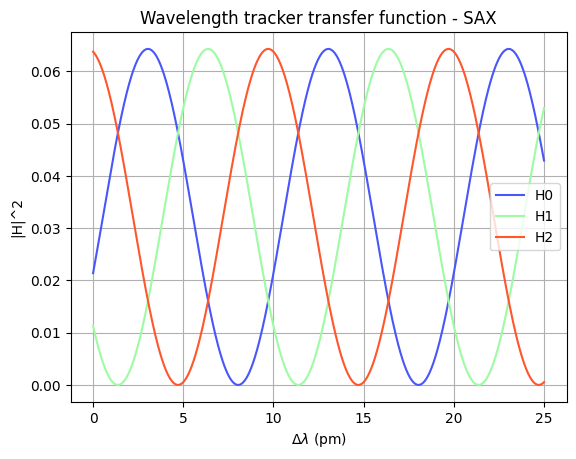

In [4]:
wls = jnp.linspace(1.55000, 1.550025, 1000)
loss_soi_dB_cm = 1
loss_soi = loss_soi_dB_cm / 10000  # dB/um

l_short = 3100
delta_l = 124858.636059777
l_large = l_short + delta_l

test = wvltracker(wl = wls, 
                  wvg_u={"wl":wls, "length": l_short, "loss":loss_soi},
                  wvg_d={"wl":wls, "length": l_large, "loss":loss_soi},)

h0 = test["in0", "out0"]
h1 = test["in0", "out1"]
h2 = test["in0", "out2"]

H0 = np.abs(h0)**2
H1 = np.abs(h1)**2
H2 = np.abs(h2)**2

wl0 = 1.55
dl_pm = (np.asarray(wls) - wl0) * 1e6  # um -> pm

plt.plot(dl_pm, H0, linestyle = '-', color = color[1], label = 'H0')
plt.plot(dl_pm, H1, linestyle = '-', color = color[5], label = 'H1')
plt.plot(dl_pm, H2, linestyle = '-', color = color[8], label = 'H2')
plt.xlabel("$\Delta \lambda$ (pm)")
plt.ylabel('|H|^2')
plt.title('Wavelength tracker transfer function - SAX')
plt.legend()
plt.grid(True)

plt.show()

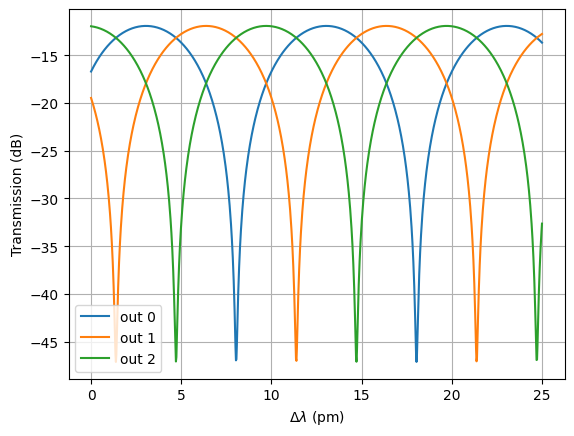

In [6]:
eps = 1e-15

H0_dB = 10 * np.log10(H0 + eps)
H1_dB = 10 * np.log10(H1 + eps)
H2_dB = 10 * np.log10(H2 + eps)


plt.plot(dl_pm, H0_dB, label="out 0")
plt.plot(dl_pm, H1_dB, label="out 1")
plt.plot(dl_pm, H2_dB, label="out 2")

plt.xlabel(r"$\Delta\lambda$ (pm)")
plt.ylabel("Transmission (dB)")
#plt.title("Wavelength tracker transfer function - SAX")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(H0)

peak_wls = np.asarray(wls)[peaks]
fsrs_pm = np.diff(peak_wls) * 1e6

print("FSR medio [pm]:", np.mean(fsrs_pm))
print("FSR std [pm]:", np.std(fsrs_pm))

FSR medio [pm]: 9.997497497415964
FSR std [pm]: 0.012512512581608348
